# Instrument Validation

Audits the query machinery and the trained heads before any claim is scored against them.
The walk gap, composition fidelity, the absorbing-state rates, the calibration slope, the
ensemble interval coverage, the identity share of what the model knows, and the pooled
column. No gate verdict is read here — that is `06_claim_evaluation`, which asserts these
verdicts before it runs.

Every number is read from an artifact committed under `results/phase_e` or `results/phase_f`.
Nothing here trains, scores, or recomputes.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import claim1_eval
from src.model import query

## Configuration

Artifact locations and the orderings used for every table below. The scored arm is the
`d10_baseline` ensemble and the frame is 2024, which is the selection season rather than the
test season.

In [2]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)

PHASE_E_DIR = REPO_ROOT / "results/phase_e"
PHASE_C_DIR = REPO_ROOT / "results/phase_c"
PHASE_D_DIR = REPO_ROOT / "results/phase_d"
PHASE_F_DIR = REPO_ROOT / "results/phase_f"

SCORED_ARM = "e11_d10_baseline"
EVAL_SEASON = 2024

LADDER_ORDER = ["no_info_league_average", "c1_raw", "c1_bucketed", "c2_bivariate",
                "c2_book_rho_reference", "c3_gbm_outcome", "c3_gbm_full", "phase_d"]
STRATUM_ORDER = ["low", "medium", "high", "all"]


def load_e(name):
    """Read one committed Phase E artifact by filename."""
    return pd.read_csv(PHASE_E_DIR / name)


def load_json_e(name):
    """Read one committed Phase E JSON artifact by filename."""
    return json.loads((PHASE_E_DIR / name).read_text())


def load_f(name):
    """Read one committed Phase F artifact by filename."""
    return pd.read_csv(PHASE_F_DIR / name)


def load_json_f(name):
    """Read one committed Phase F summary by filename."""
    return json.loads((PHASE_F_DIR / name).read_text())


## Run parameters read from their owner modules

The eval frame thresholds and the query machinery defaults are imported, so a moved constant
breaks this cell rather than quietly disagreeing with the artifacts.

In [3]:
pd.Series({
    "eval season": EVAL_SEASON,
    "stabilization anchor, PA": claim1_eval.STABILIZATION_N_STAR,
    "stratum boundaries in prior PA": str(claim1_eval.STRATUM_BOUNDARIES),
    "eval season PA floor": claim1_eval.MIN_EVAL_PA,
    "committed censoring sweep": str(claim1_eval.MIN_EVAL_PA_SENSITIVITY),
    "count states in the chain": len(query.COUNT_STATES),
    "absorbing states": str(query.ABSORBING_KEYS),
    "pitches drawn per count cell": query.DEFAULT_N_PITCHES,
}, name="value").to_frame()

,value
eval season,2024
"stabilization anchor, PA",226
stratum boundaries in prior PA,"(113, 452)"
eval season PA floor,10
committed censoring sweep,"(10, 25, 50)"
count states in the chain,12
absorbing states,"('bb', 'k', 'hbp', 'bip')"
pitches drawn per count cell,6


## Eval frame coverage

How many batter by hand rows survive the eval season PA floor, and what the filter removes.
Dropped rows have a markedly lower wOBA than scored rows in every stratum, which is why the
floor is swept rather than fixed.

In [4]:
report = load_json_e("e_report.json")
coverage = report["e4_calibration"]["coverage"]
for key, value in coverage.items():
    if key != "by_stratum":
        print(f"{key}: {value}")

eval_season: 2024
actual_groups: 1279
dropped_below_min_eval_pa: 130
min_eval_pa: 10
dropped_no_prediction: 0
scored_groups: 1149


In [5]:
stratum_coverage = pd.DataFrame(coverage["by_stratum"]).T
stratum_coverage = stratum_coverage.loc[
    [s for s in STRATUM_ORDER if s in stratum_coverage.index]]
stratum_coverage.round(4)

,scored,dropped,share_dropped,mean_woba_scored,mean_woba_dropped
low,380.0,85.0,0.1828,0.2715,0.1979
medium,280.0,33.0,0.1054,0.2862,0.2245
high,489.0,12.0,0.0240,0.3042,0.1730


## Composition fidelity on a matched population

The composed rates are compared against the population they actually score, using the same
trained hitter set and the same PA weights. The unmatched comparison averaged the model over
hitters holding a trained embedding row and the observation over every plate appearance, and
selection into having a row is selection on exposure.

In [18]:
matched = load_e("e1_matched_population.csv")
matched.round(5)

,window,population,n_pa,n_groups,bb,k,hbp,bip
0,train,pooled_all,1526308.0,NaN,0.08042,0.22338,0.01049,0.68571
1,train,matched,770182.0,1069.0,0.08312,0.23066,0.01153,0.67469
2,eval,pooled_all,181388.0,NaN,0.07950,0.22712,0.01114,0.68224
3,eval,matched,169589.0,1074.0,0.07994,0.22488,0.01127,0.68391


In [19]:
fidelity = pd.DataFrame(report["e1_matched_population"]).T
fidelity[["modelled", "eval_matched", "relative_error_vs_eval_matched",
          "pass_vs_eval_matched", "tolerance"]].round(5)

,modelled,eval_matched,relative_error_vs_eval_matched,pass_vs_eval_matched,tolerance
bb,0.085377,0.07994,0.068015,False,0.02
k,0.219644,0.224879,-0.023279,False,0.02
hbp,0.010882,0.011268,-0.034298,True,0.2
bip,0.684097,0.683912,0.00027,True,0.02


## Where the walk gap goes

The headline composition failure decomposed into owners. A population artifact, a structural
property of the count chain measured without the model at all, the pitch resampler, and a
remainder that no step claims.

In [20]:
structure = load_json_e("e10_structure_summary.json")
for key, value in structure.items():
    print(f"{key}: {value}")

n_pa: 1501600
n_pitchers: 1705
observed_bb: 0.0811154768247203
pooled_chain_bb: 0.08169570438963587
per_pitcher_chain_bb: 0.08228130735972017
structural_bb_bias_pooled: 0.0005802275649155753
structural_bb_bias_per_pitcher: 0.0011658305349998704
jensen_term_bb: 0.0005856029700842952
structural_bb_bias_relative: 0.014372479588809828
residual_walk_excess: 0.002259999999999998
share_of_residual_explained: 0.5158542190264918
structural_k_bias_relative: 0.004419014927336651


In [21]:
resampler = load_json_e("e7_resampler_summary.json")
take_mass = load_json_e("e9_take_mass_summary.json")
print(f"resampler channel one, surface: {take_mass['delta_bb_channel_1_surface']:.6f}")
print(f"resampler channel two, take mass: {take_mass['delta_bb_channel_2_take_mass']:.6f}")
print(f"resampler both channels: {take_mass['delta_bb_both_channels']:.6f}")
print(f"residual walk excess: {take_mass['residual_walk_excess']:.6f}")

resampler channel one, surface: 0.000932
resampler channel two, take mass: -0.000960
resampler both channels: -0.000028
residual walk excess: 0.002260


## The swing head is not the owner

The head was the standing suspect for the walk gap. Scored on held out real pitches it comes
in with the wrong sign in the three ball counts that would have to carry the effect.

In [22]:
swing = load_json_e("e6_swing_summary.json")
for key, value in swing.items():
    print(f"{key}: {value}")

arm: d10_baseline
seeds: [0, 1, 2, 3, 4]
eval_season: 2024
n_pitches: 705344
overall_observed: 0.4779752858179839
overall_predicted: 0.47925575717386953
overall_relative_gap: 0.0026789488784850508
three_ball_observed: 0.5927032661570535
three_ball_predicted: 0.6040052480569663
three_ball_relative_gap: 0.019068533185572223
under_three_ball_relative_gap: 0.000833706937429568
max_abs_count_relative_gap: 0.08739834697711174


## Composition rate errors by absorbing state

The four absorbing rates and the model against observed relative error, for the pooled chain
and the per pitcher chain. The strikeout row is the one that fails without an owner.

In [23]:
structure_table = load_e("e10_structure.csv")
structure_table.round(5)

,aggregation,rate_bb,rate_k,rate_hbp,rate_bip,relerr_bb,relerr_k,relerr_hbp,relerr_bip
0,observed,0.08112,0.22184,0.01058,0.68647,0.00000,0.00000,0.00000,0.00000
1,pooled_chain,0.08170,0.22146,0.01064,0.68621,0.00715,-0.00171,0.00567,-0.00038
2,per_pitcher_chain,0.08228,0.22282,0.01056,0.68434,0.01437,0.00442,-0.00123,-0.00311


## Calibration slope by stratum

Whether a predicted wOBA of X corresponds to an observed wOBA of X. A slope below one means
predictions are spread wider than outcomes. This tracks exposure by design and is reported
unscored.

In [24]:
calibration = load_e("e4_calibration.csv")
calibration["stratum"] = pd.Categorical(calibration["stratum"], STRATUM_ORDER, ordered=True)
calibration.sort_values("stratum").set_index("stratum").round(4)

,n_hitters,pa,mean_pred,mean_obs,intercept,slope,slope_se,slope_z_vs_one
stratum,,,,,,,,
low,380,32781.0,0.3031,0.2925,0.1322,0.5289,0.0962,-4.8981
medium,280,36877.0,0.3156,0.3023,0.0928,0.6639,0.1066,-3.1527
high,489,111114.0,0.3344,0.3186,-0.0153,0.9984,0.0894,-0.0176
all,1149,180772.0,0.3249,0.3106,0.0372,0.8414,0.0585,-2.7107


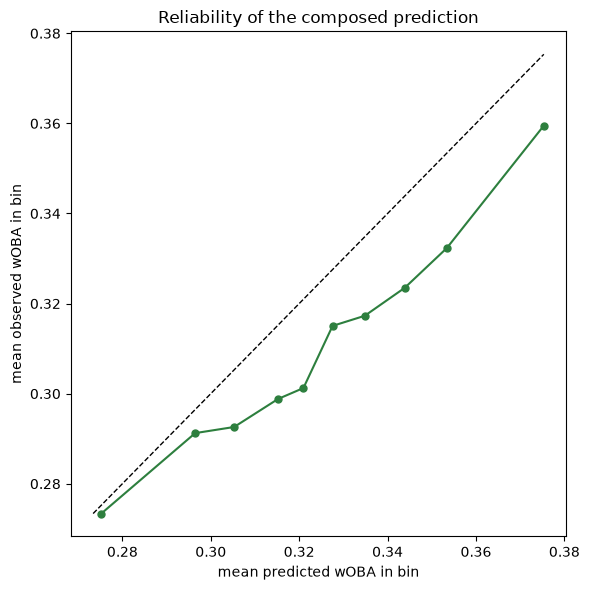

In [25]:
reliability = load_e("e4_reliability.csv")
figure, axis = plt.subplots(figsize=(6, 6))
axis.plot(reliability["mean_pred"], reliability["mean_obs"], "o-", color="#2d7f3e", ms=5)
limits = [min(reliability["mean_pred"].min(), reliability["mean_obs"].min()),
          max(reliability["mean_pred"].max(), reliability["mean_obs"].max())]
axis.plot(limits, limits, color="black", lw=1, ls="--")
axis.set_xlabel("mean predicted wOBA in bin")
axis.set_ylabel("mean observed wOBA in bin")
axis.set_title("Reliability of the composed prediction")
figure.tight_layout()
plt.show()

## Ensemble interval coverage

A separate honesty property from the calibration slope. It asks whether an X percent interval
covers X percent of outcomes. The seed only interval is the ensemble alone and the second
kind adds the target noise, which is the fair test.

In [26]:
coverage_json = load_json_e("e14_coverage.json")
print(f"mean seed sd: {coverage_json['mean_seed_sd']:.6f}")
print(f"mean target noise sd: {coverage_json['mean_target_noise_sd']:.6f}")
print(f"scored groups: {coverage_json['n_scored_groups']}")
print(f"pre registered expectation held: {coverage_json['expectation']['held']}")

mean seed sd: 0.004319
mean target noise sd: 0.053415
scored groups: 1149
pre registered expectation held: True


In [27]:
interval_coverage = load_e("e14_coverage.csv")
interval_coverage["slice"] = pd.Categorical(
    interval_coverage["slice"],
    [s for s in STRATUM_ORDER if s in set(interval_coverage["slice"])] +
    [s for s in interval_coverage["slice"].unique() if s not in STRATUM_ORDER],
    ordered=True)
interval_coverage.sort_values(["interval", "slice", "nominal"])[
    ["interval", "slice", "n_groups", "nominal", "empirical",
     "ci_low", "ci_high", "gap", "mean_half_width"]].round(4).reset_index(drop=True)

,interval,slice,n_groups,nominal,empirical,ci_low,ci_high,gap,mean_half_width
0,seed_only,low,380,0.50,0.0263,0.0144,0.0478,-0.4737,0.0032
1,seed_only,low,380,0.80,0.0553,0.0364,0.0830,-0.7447,0.0061
2,seed_only,low,380,0.95,0.0947,0.0692,0.1284,-0.8553,0.0093
3,seed_only,medium,280,0.50,0.0321,0.0170,0.0599,-0.4679,0.0030
4,seed_only,medium,280,0.80,0.0679,0.0439,0.1035,-0.7321,0.0057
5,seed_only,medium,280,0.95,0.0964,0.0671,0.1367,-0.8536,0.0087
6,seed_only,high,489,0.50,0.0348,0.0218,0.0550,-0.4652,0.0026
7,seed_only,high,489,0.80,0.0798,0.0589,0.1072,-0.7202,0.0050
8,seed_only,high,489,0.95,0.1166,0.0911,0.1480,-0.8334,0.0077
9,seed_only,all,1149,0.50,0.0313,0.0227,0.0431,-0.4687,0.0029


## Linear decodability of the platoon signal

A ridge probe on the frozen embeddings against the empirical Bayes posterior split. A linear
read out is deliberately weak, so this bounds what is linearly decodable rather than
demonstrating what the representation contains. The shuffled null is not centred on zero,
because out of fold predictions of noise are anti correlated with the target.

In [32]:
probe = load_json_e("e14_probe.json")["probe"]
print(f"hitters with a C.2 split: {probe['exclusions']['hitters_with_a_c2_split']}")
print(f"cold start excluded: {probe['exclusions']['cold_start_excluded']}")
print(f"hitters probed: {probe['exclusions']['hitters_probed']}")
print(f"embedding dimension: {probe['features']['embedding_dim']}")
print(f"seed handling: {probe['features']['seed_handling']}")

hitters with a C.2 split: 630
cold start excluded: 97
hitters probed: 533
embedding dimension: 32
seed handling: per-seed decode, correlations averaged; raw embeddings NEVER averaged


In [33]:
probe_results = probe.get("results", probe)
print(json.dumps(probe_results, indent=2)[:1400])

{
  "target": {
    "source_module": "src/analysis/c2_bivariate_eb.py::predict",
    "column": "pred_woba, pivoted on p_throws, split = L - R",
    "quantity": "C.2 empirical-Bayes POSTERIOR MEAN split (not the raw observed split)",
    "hyper_parameters_committed_at": "results/phase_c/c2_prior_parameters.csv"
  },
  "features": {
    "source": "results/checkpoints/d10_baseline_s{0..4}.pt, key model.embedding.weight",
    "vocabulary": "data/processed/phase_d5/manifest.json::vocabulary",
    "seed_handling": "per-seed decode, correlations averaged; raw embeddings NEVER averaged",
    "embedding_dim": 32
  },
  "exclusions": {
    "hitters_with_a_c2_split": 630,
    "cold_start_excluded": 97,
    "hitters_probed": 533
  },
  "cross_validation": "GroupKFold(5) on batter id, RidgeCV inside each fold",
  "by_stand": {
    "pooled": {
      "real": {
        "n_hitters": 533,
        "n_seeds": 5,
        "pearson": 0.1952975239726944,
        "pearson_ci_low": 0.12396639334135741,
        

## The balls in play value gap

The composed value of a ball in play against the observed value. The pre-registered
measurement seam explanation came in at the wrong sign, and era drift in the frozen value
table carries the gap instead, leaving a residual that absorbs the un orthogonalised
interaction.

In [34]:
bip_value = load_json_e("e13_bip_value.json")
pd.Series({
    "value modelled": bip_value["gap_being_explained"]["value_modelled_bip"],
    "value observed": bip_value["gap_being_explained"]["value_observed_bip"],
    "gap": bip_value["gap_being_explained"]["gap"],
    "check A share of gap": bip_value["check_a_measured_share_seam"]["share_of_gap"],
    "conditional drift": bip_value["check_b_era_drift"]["conditional_drift"],
    "conditional share of gap": bip_value["check_b_era_drift"]["conditional_share_of_gap"],
    "residual unexplained": bip_value["residual_unexplained"],
    "residual share of gap": bip_value["residual_share_of_gap"],
}, name="value").to_frame().round(6)

,value
value modelled,0.378642
value observed,0.363526
gap,0.015116
check A share of gap,-1.068685
conditional drift,0.028836
conditional share of gap,1.907627
residual unexplained,0.002435
residual share of gap,0.161057


## Which tensor build produced the numbers below

Every Phase F summary carries the sha256 of its build manifest, the train seasons, the arm,
the seeds, and the git revision. The stamp is printed so a reader can tell what was scored
without inferring it from module defaults.

In [35]:
stamp = load_json_f("f4_process_summary.json")["provenance"]
pd.Series({
    "data dir": stamp["data_dir"],
    "manifest sha256": stamp["manifest_sha256"][:16],
    "train seasons": f"{min(stamp['train_seasons'])} to {max(stamp['train_seasons'])}",
    "arm": stamp["arm"],
    "seeds": str(stamp["seeds"]),
    "eval season": stamp["eval_season"],
    "git revision": stamp["git_revision"][:12],
}, name="value").to_frame()

,value
data dir,data/processed/phase_d5
manifest sha256,cc01c16ef6a9835d
train seasons,2015 to 2023
arm,d10_baseline
seeds,"[0, 1, 2, 3, 4]"
eval season,2024
git revision,5ccaa90cbd34


## How much of what the model knows is the hitter

Every gate above scores a composed scalar, which cannot say whether the model learned pitch
level process at all. This is held out negative log likelihood per head against two
references. Cold start replaces the hitter embedding with the reserved zero row, so the gap
is what identity buys. The frequency table is a Laplace smoothed count of real pitches fit on
train seasons only, so the gap is what the model buys over knowing nothing but the count and
the two handednesses.

In [36]:
HEAD_ORDER = ['swing', 'contact', 'split', 'ev', 'la', 'spray']

process = load_json_f("f4_process_summary.json")
process_table = pd.DataFrame([process["by_head"][head] for head in HEAD_ORDER]).set_index("head")
process_table[["n_rows", "model_nll", "cold_start_nll", "frequency_reference_nll",
               "identity_gain", "gain_vs_reference", "identity_share_of_gain"]].round(4)

,n_rows,model_nll,cold_start_nll,frequency_reference_nll,identity_gain,gain_vs_reference,identity_share_of_gain
head,,,,,,,
swing,705344,0.4185,0.4441,0.6607,0.0255,0.2421,0.1055
contact,337137,0.4177,0.4398,0.5412,0.0221,0.1235,0.1790
split,258502,0.7587,0.7684,0.8025,0.0096,0.0438,0.2200
ev,122316,2.9800,3.0461,3.1700,0.0661,0.1900,0.3480
la,122316,2.9097,2.9407,3.1658,0.0310,0.2561,0.1210
spray,121153,2.9152,2.9502,3.1732,0.0350,0.2580,0.1355


In [37]:
# the share of eval pitches whose hitter has no trained row, which dilutes identity gain down
print(f"output: {process['cold_start_share_of_eval_pitches']:.4f}")

output: 0.0646


## The contact head is biased in the wrong direction to own the strikeout shortfall

The open residual is a strikeout rate that comes in too low against the population matched
reference. Under predicting contact means over predicting whiffs, which pushes strikeouts up.
So a negative contact gap in every count runs against the residual rather than causing it.
Effect sizes here are unclustered, and batter clustered intervals were not computed.

In [38]:
heads = load_json_f("f3_heads_summary.json")
pd.Series({
    "swing overall relative gap": heads["overall_relative_gap"]["swing"],
    "contact overall relative gap": heads["overall_relative_gap"]["contact"],
    "largest absolute relative gap, contact": heads["max_abs_relative_gap_by_head"]["contact"],
    "largest absolute relative gap, swing": heads["max_abs_relative_gap_by_head"]["swing"],
}, name="value").to_frame().round(5)

,value
swing overall relative gap,0.00268
contact overall relative gap,-0.01398
"largest absolute relative gap, contact",0.02050
"largest absolute relative gap, swing",0.08740


In [39]:
head_calibration = load_f("f3_head_calibration.csv")
contact_by_count = head_calibration[(head_calibration["head"] == "contact")
                                    & (head_calibration["grouping"] == "count")]
contact_by_count[["cell", "n_rows", "observed", "predicted", "relative_gap"]].round(5)

,cell,n_rows,observed,predicted,relative_gap
20,0-0,56754,0.75080,0.74059,-0.01360
21,0-1,45048,0.73963,0.72915,-0.01418
22,0-2,24564,0.74300,0.72777,-0.02050
23,1-0,29136,0.75686,0.75109,-0.00763
24,1-1,38621,0.76075,0.75108,-0.01271
25,1-2,40299,0.75694,0.74566,-0.01490
26,2-0,9576,0.79678,0.78335,-0.01686
27,2-1,20929,0.78891,0.77276,-0.02047
28,2-2,38094,0.78863,0.77680,-0.01500
29,3-0,672,0.87202,0.85366,-0.02106


In [40]:
# the sign check that clears the head, stated as a count rather than an interval
negative_counts = int((contact_by_count["relative_gap"] < 0).sum())
print(f"output: {negative_counts} of {len(contact_by_count)}")

output: 12 of 12


## Accuracy once handedness is pooled away

Every score above is a batter by season by pitcher hand triple, because the claim is about
the platoon split. This collapses the hand column and reruns the same referee, answering how
well the model predicts a hitter overall. Predictions are pooled by prior side specific
exposure, never by eval season exposure, which would condition the forecast on the held out
sample. Two limits apply. Neither named gate opponent is in this table, since C.2 needs its
fitted priors and C.3 needs a refit, so nothing here is a gate. And the strata were
calibrated on side specific exposure, so pooled strata select a different population and do
not compare to the strata anywhere else.

In [41]:
pooled = load_f("f5_pooled_scores.csv")
pooled[["model", "stratum", "n_hitters", "pa_weighted_rmse", "noise_floor",
        "rank_corr_weighted", "skill_vs_no_info"]].round(5)

,model,stratum,n_hitters,pa_weighted_rmse,noise_floor,rank_corr_weighted,skill_vs_no_info
0,phase_d,low,161,0.04900,0.03959,0.21825,0.14308
1,phase_d,medium,108,0.03647,0.03091,0.28985,0.12699
2,phase_d,high,348,0.03757,0.02575,0.50213,0.17213
3,phase_d,all,617,0.03904,0.02863,0.48611,0.16095
4,c1_raw,low,161,0.08358,0.03959,-0.03236,-1.49271
5,c1_raw,medium,108,0.05656,0.03091,-0.01965,-1.10004
6,c1_raw,high,348,0.03629,0.02575,0.51386,0.22756
7,c1_raw,all,617,0.04802,0.02863,0.39584,-0.26934
8,c1_bucketed,low,161,0.05476,0.03959,-0.12494,-0.07011
9,c1_bucketed,medium,108,0.04506,0.03091,0.03479,-0.33321


In [42]:
pooled_summary = load_json_f("f5_pooled_summary.json")
print(f"output: {pooled_summary['pooling_weight']}")
print(f"output: {', '.join(pooled_summary['rungs_omitted'])}")

output: prior side-specific denominator PA, normalized within batter
output: c2_bivariate, c2_book_rho_reference, c3_gbm_outcome, c3_gbm_full


## What this notebook establishes

- The walk gap is decomposed rather than carried. A population artifact and a structural
  property of the count chain own most of it, the swing head and the resampler are
  exonerated, and a remainder is recorded as open.
- Calibration tracks exposure as designed, and ensemble intervals under cover, which is a
  reported limitation rather than a rebuild.
- The model learned process, not only a scalar. Held out likelihood beats both the cold start
  and the frequency reference on all six heads. Identity is a real but minority share of that
  gain, largest on exit velocity, which is consistent with the platoon claim failing its gate
  while the model still ranks hitters better than any ladder rung.
- The contact head is cleared as the owner of the strikeout shortfall. It is biased in the
  direction that produces more strikeouts, not fewer, so correcting it would widen the gap.
- With handedness pooled away the model beats the no information reference in every stratum,
  including low exposure, where both trailing average variants do not.
